<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Do histograma à decisão: threshold

O histograma, visto na aula passada, é mais que um diagnóstico: ele orienta a primeira decisão automática que um sistema de visão toma. O **threshold** (limiarização) converte uma imagem em tons de cinza em uma imagem binária, separando os pixels em dois grupos a partir de um valor de corte.

Toda segmentação começa aqui: antes de detectar, contar ou medir qualquer objeto, é preciso decidir o que é figura e o que é fundo.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


## O histograma como mapa da decisão

A imagem de referência é convertida para tons de cinza e o histograma é recalculado. A pergunta agora é diferente da aula anterior: onde passar a linha de corte que separa os grupos de pixels?

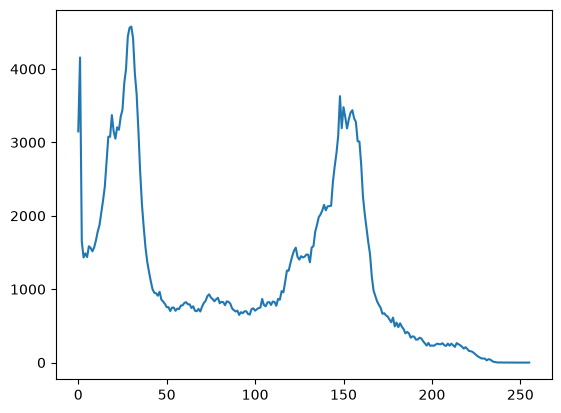

In [3]:
img = cv2.imread('../imgs/perfil.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.plot(hist)
plt.show()

## Threshold fixo

A função `cv2.threshold` recebe o valor de corte e o valor máximo. Todo pixel acima do corte vira 255; o resto vira 0. O retorno tem dois elementos: o limiar usado e a imagem binária.

In [6]:
# cv2.threshold()

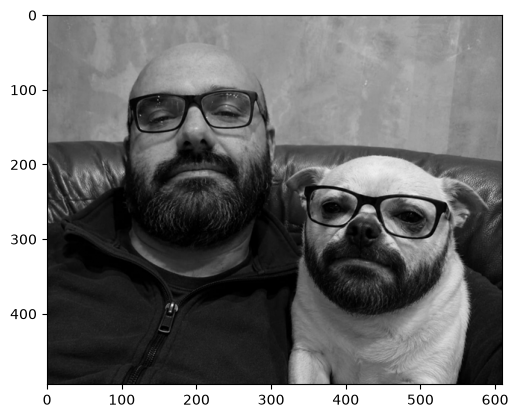

In [7]:
plt.imshow(gray, cmap='gray')

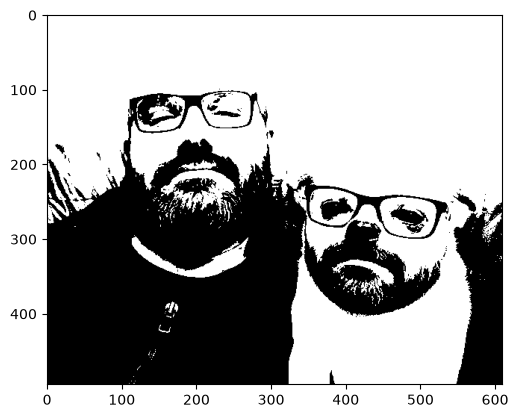

In [8]:
valor, binaria = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

plt.imshow(binaria, cmap='gray')
plt.show()

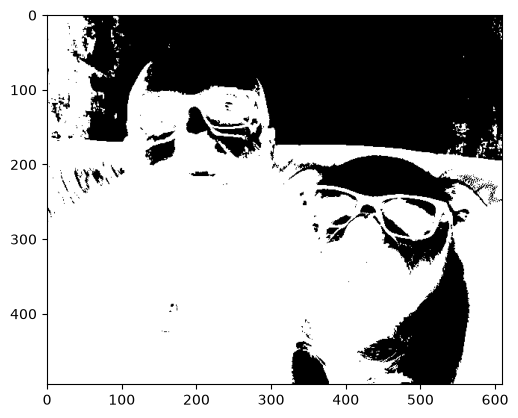

In [9]:
valor, inversa = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

plt.imshow(inversa, cmap='gray')
plt.show()

O corte em 127 é arbitrário. Mover o limiar muda o que sobrevive na imagem binária, e o histograma mostra por quê: cada posição da linha de corte reparte a distribuição em dois volumes diferentes.

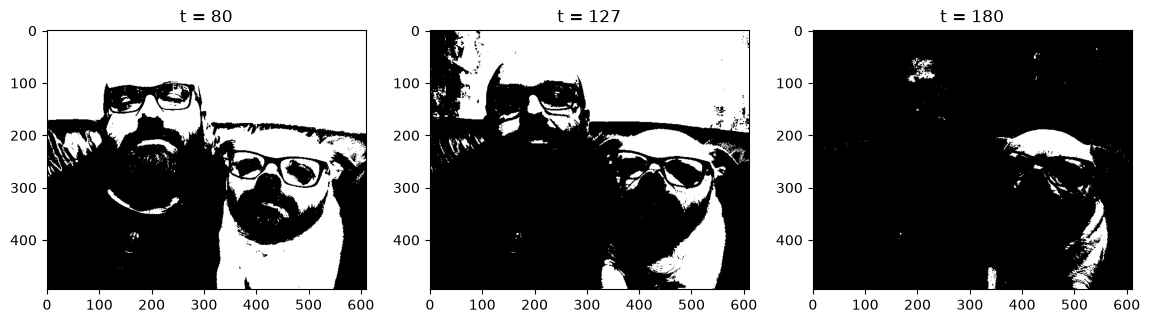

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, t in zip(axes, [80, 127, 180]):
    _, b = cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)
    ax.imshow(b, cmap='gray')
    ax.set_title(f't = {t}')
plt.show()

## Otsu: deixando o histograma decidir

Escolher o limiar no olho funciona para uma imagem, mas não escala. O método de **Otsu** varre o histograma e escolhe automaticamente o corte que melhor separa os dois grupos. É literalmente o histograma tomando a decisão.

Basta somar a flag `THRESH_OTSU` e passar 0 no lugar do limiar. Uma ressalva: Otsu assume um histograma com dois grupos bem definidos (bimodal). No retrato, que não tem essa cara, o resultado é apenas ilustrativo; ele vai brilhar de verdade na aplicação do fim da aula.

limiar escolhido por Otsu: 89.0


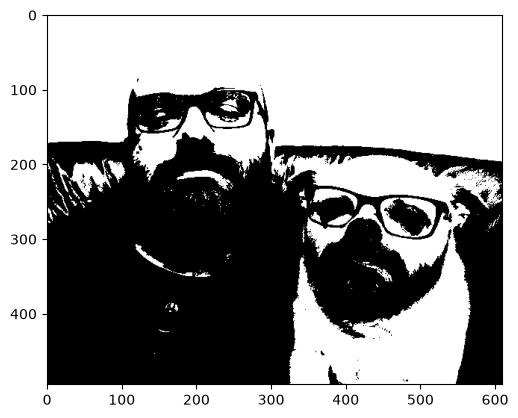

In [11]:
valor_otsu, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('limiar escolhido por Otsu:', valor_otsu)

plt.imshow(otsu, cmap='gray')
plt.show()

## Quando o limiar global falha

Um único corte para a imagem inteira supõe iluminação uniforme. Uma rampa de luz simulada sobre a imagem quebra essa suposição: o mesmo objeto fica claro de um lado e escuro do outro.

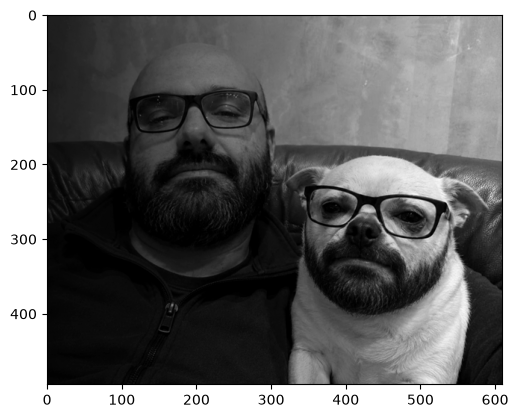

In [12]:
h, w = gray.shape
rampa = np.tile(np.linspace(0.2, 1.0, w), (h, 1))
desigual = (gray * rampa).astype(np.uint8)

plt.imshow(desigual, cmap='gray')
plt.show()

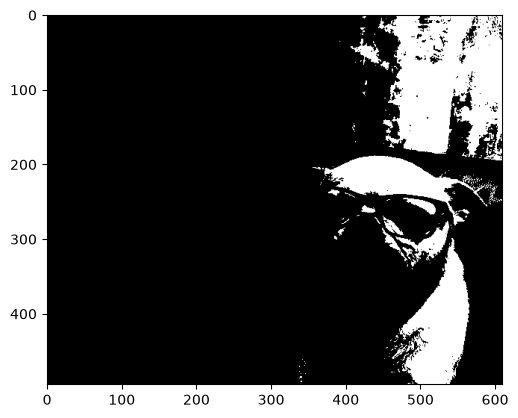

In [13]:
_, global_falha = cv2.threshold(desigual, 127, 255, cv2.THRESH_BINARY)

plt.imshow(global_falha, cmap='gray')
plt.show()

O lado escuro desaparece por inteiro: nenhum corte único resolve os dois lados ao mesmo tempo.

## Threshold adaptativo

O `cv2.adaptiveThreshold` calcula um limiar diferente para cada região da imagem, usando a vizinhança de cada pixel. Os dois últimos parâmetros são o tamanho da vizinhança (ímpar) e uma constante subtraída da média.

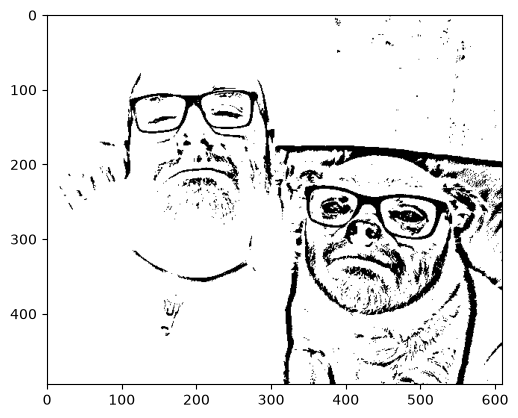

In [14]:
adaptativa = cv2.adaptiveThreshold(desigual, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, 21, 10)

plt.imshow(adaptativa, cmap='gray')
plt.show()

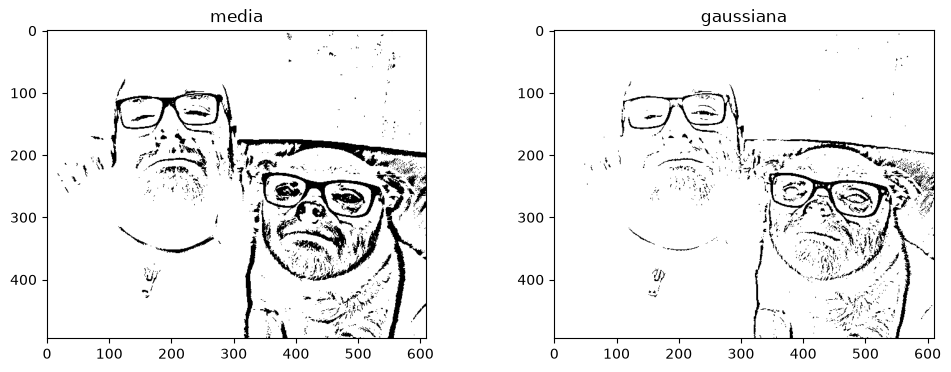

In [15]:
gaussiana = cv2.adaptiveThreshold(desigual, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 21, 10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(adaptativa, cmap='gray')
axes[0].set_title('media')
axes[1].imshow(gaussiana, cmap='gray')
axes[1].set_title('gaussiana')
plt.show()

A versão adaptativa recupera a estrutura nos dois lados da rampa, porque cada região decide com base na própria vizinhança.

## Aplicação: separando moedas do fundo

Fechando o ciclo com um caso concreto: as moedas sobre a mesa, uma imagem com dois grupos claros no histograma (mesa clara, moedas escuras), o cenário ideal de Otsu. Um borrão leve antes do threshold reduz o ruído. Como a mesa é mais clara que as moedas, a versão invertida (`THRESH_BINARY_INV`) deixa as moedas em branco, a convenção usual para a figura de interesse. As etapas seguintes do pipeline ficam para a disciplina de Processamento Digital de Imagens.

In [18]:
moedas = cv2.imread('../imgs/brasil-moedas.jpg')
moedas_gray = cv2.cvtColor(moedas, cv2.COLOR_BGR2GRAY)
suave = cv2.GaussianBlur(moedas_gray, (7, 7), 0)

valor_m, mascara = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('limiar de Otsu para as moedas:', valor_m)

limiar de Otsu para as moedas: 208.0


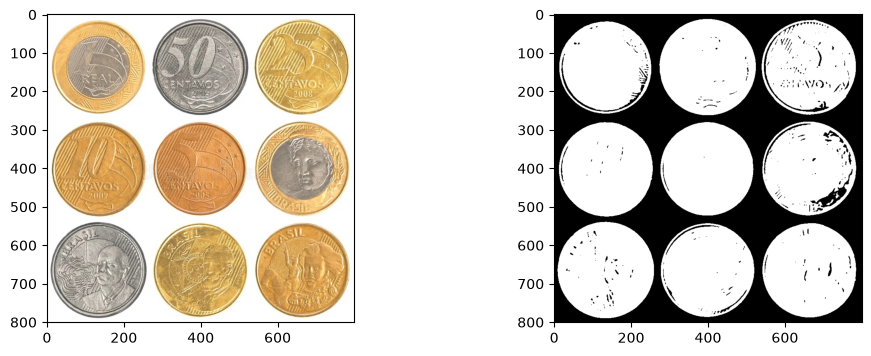

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(moedas, cv2.COLOR_BGR2RGB))
axes[1].imshow(mascara, cmap='gray')
plt.show()

## Síntese

O caminho da aula: o histograma descreve a distribuição de intensidades; o threshold usa essa distribuição para tomar uma decisão binária; Otsu automatiza a escolha do corte; e o threshold adaptativo resolve o caso em que a iluminação não é uniforme. A imagem binária resultante é a porta de entrada da segmentação, assunto que volta com força em Processamento Digital de Imagens.